In [19]:
# This is for individual files.

library(tidyverse)
library(vroom)
library(data.table)
library(pheatmap)
library(preprocessCore)
library(purrr)
library(RColorBrewer)
library(ggpubr)
library(ggpointdensity)

reverse_complement <- function(dna_seq) {
  complement <- c("A" = "T", "T" = "A", "C" = "G", "G" = "C")
  nucleotides <- unlist(strsplit(dna_seq, ""))
  complement_nucleotides <- complement[nucleotides]
  reverse_complement_seq <- paste(rev(complement_nucleotides), collapse = "")
  return(reverse_complement_seq)
}

############# Look at Tau and PSI #################
# Calculate Tau for each gene.
calculate_tau <- function(row){
  # Remove NA values from the row
  non_na_row <- row[!is.na(row)]
  # If the row is empty after removing NAs, return NA
  if (length(non_na_row) < 20) {
    return(NA)
  }
  # Normalize the row by dividing by the max value of the non-NA row
  norm_row <- non_na_row / max(non_na_row)
  # Calculate tau using the number of non-NA values
  tau <- sum(1 - norm_row) / (length(non_na_row) - 1)
  return(tau)
}

# upsilon is the metric for PSI. We add 1 so that values close to 0 will not be inflated.
calculate_upsilon <- function(row) {
  # Remove NA values from the row
  non_na_row <- row[!is.na(row)]
  # If the row is empty after removing NAs, return NA
  if (length(non_na_row) < 20) {
    return(NA)
  }
  # Add 1 to every value in the row.
  non_na_row <- non_na_row + 1
  # Normalize the row by dividing by the max value of the non-NA row
  norm_row <- non_na_row / max(non_na_row)
  # Calculate tau using the number of non-NA values
  tau <- sum(1 - norm_row) / (length(non_na_row) - 1)
  return(tau * 2)
}

output_filepath <- "/mnt/dawnccle2/processed_data/reprocess_250221/count_normalized_v4_merged/figure_outputs"
# Now I kinda want to plot the heatmap. 
final_psi_table_filtered <- fread("/mnt/dawnccle2/processed_data/reprocess_250221/count_normalized_v4_merged/WT_all_samples_PSI_count_table_individual.csv")


In [2]:
final_psi_table_filtered <- final_psi_table_filtered %>% 
  filter(!(condition %in% c("K562WT", "K562K700E"))) %>% 
  filter(!(condition %in% c("JHOM1", "RVH421", "KNS60", "OVTOKO"))) %>% 
  mutate(total_count = included_count + skipped_count) %>%
  filter(total_count >= 30) %>%
  mutate(index_offset = paste(index, offset, sep = "__")) %>% 
  separate(offset, into = c("upstream_offset", "downstream_offset", "const_offset"), sep = ":") %>% 
  mutate(upstream_offset = as.integer(upstream_offset)) %>% 
  mutate(downstream_offset = as.integer(downstream_offset)) %>%
  mutate(const_offset = as.integer(const_offset)) %>% 
  filter(abs(upstream_offset) != 1 & abs(downstream_offset)!= 1) %>% 
  dplyr::select(-upstream_offset, -downstream_offset, -const_offset) %>% 
  dplyr::select(-index) %>%
  mutate(PSI = included_count/(included_count + skipped_count))

dt <- as.data.table(final_psi_table_filtered)

# Compute PSI by condition efficiently
psi_by_condition <- dt[, .(PSI = mean(PSI, na.rm = TRUE), num_rep = .N), by = .(condition, index_offset)][
  num_rep >= 2, .(condition, index_offset, PSI)]  # Filter out groups with <2 replicates

psi_table_pivot <- psi_by_condition %>%
  select(condition, index_offset, PSI) %>%
  pivot_wider(names_from = c(condition), values_from = PSI)

psi_table_pivot_sample <- final_psi_table_filtered %>%
  select(sample, index_offset, PSI) %>%
  pivot_wider(names_from = c(sample), values_from = PSI) 

# Convert to matrix.
psi_table_mat <- as.matrix(psi_table_pivot_sample %>% select(-index_offset))
rownames(psi_table_mat) <- psi_table_pivot_sample$index_offset

Warning message:
“Removed 6832 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 12839 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 8704 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 7652 rows containing missing values or values outside the scale range
(`geom_point()`).”


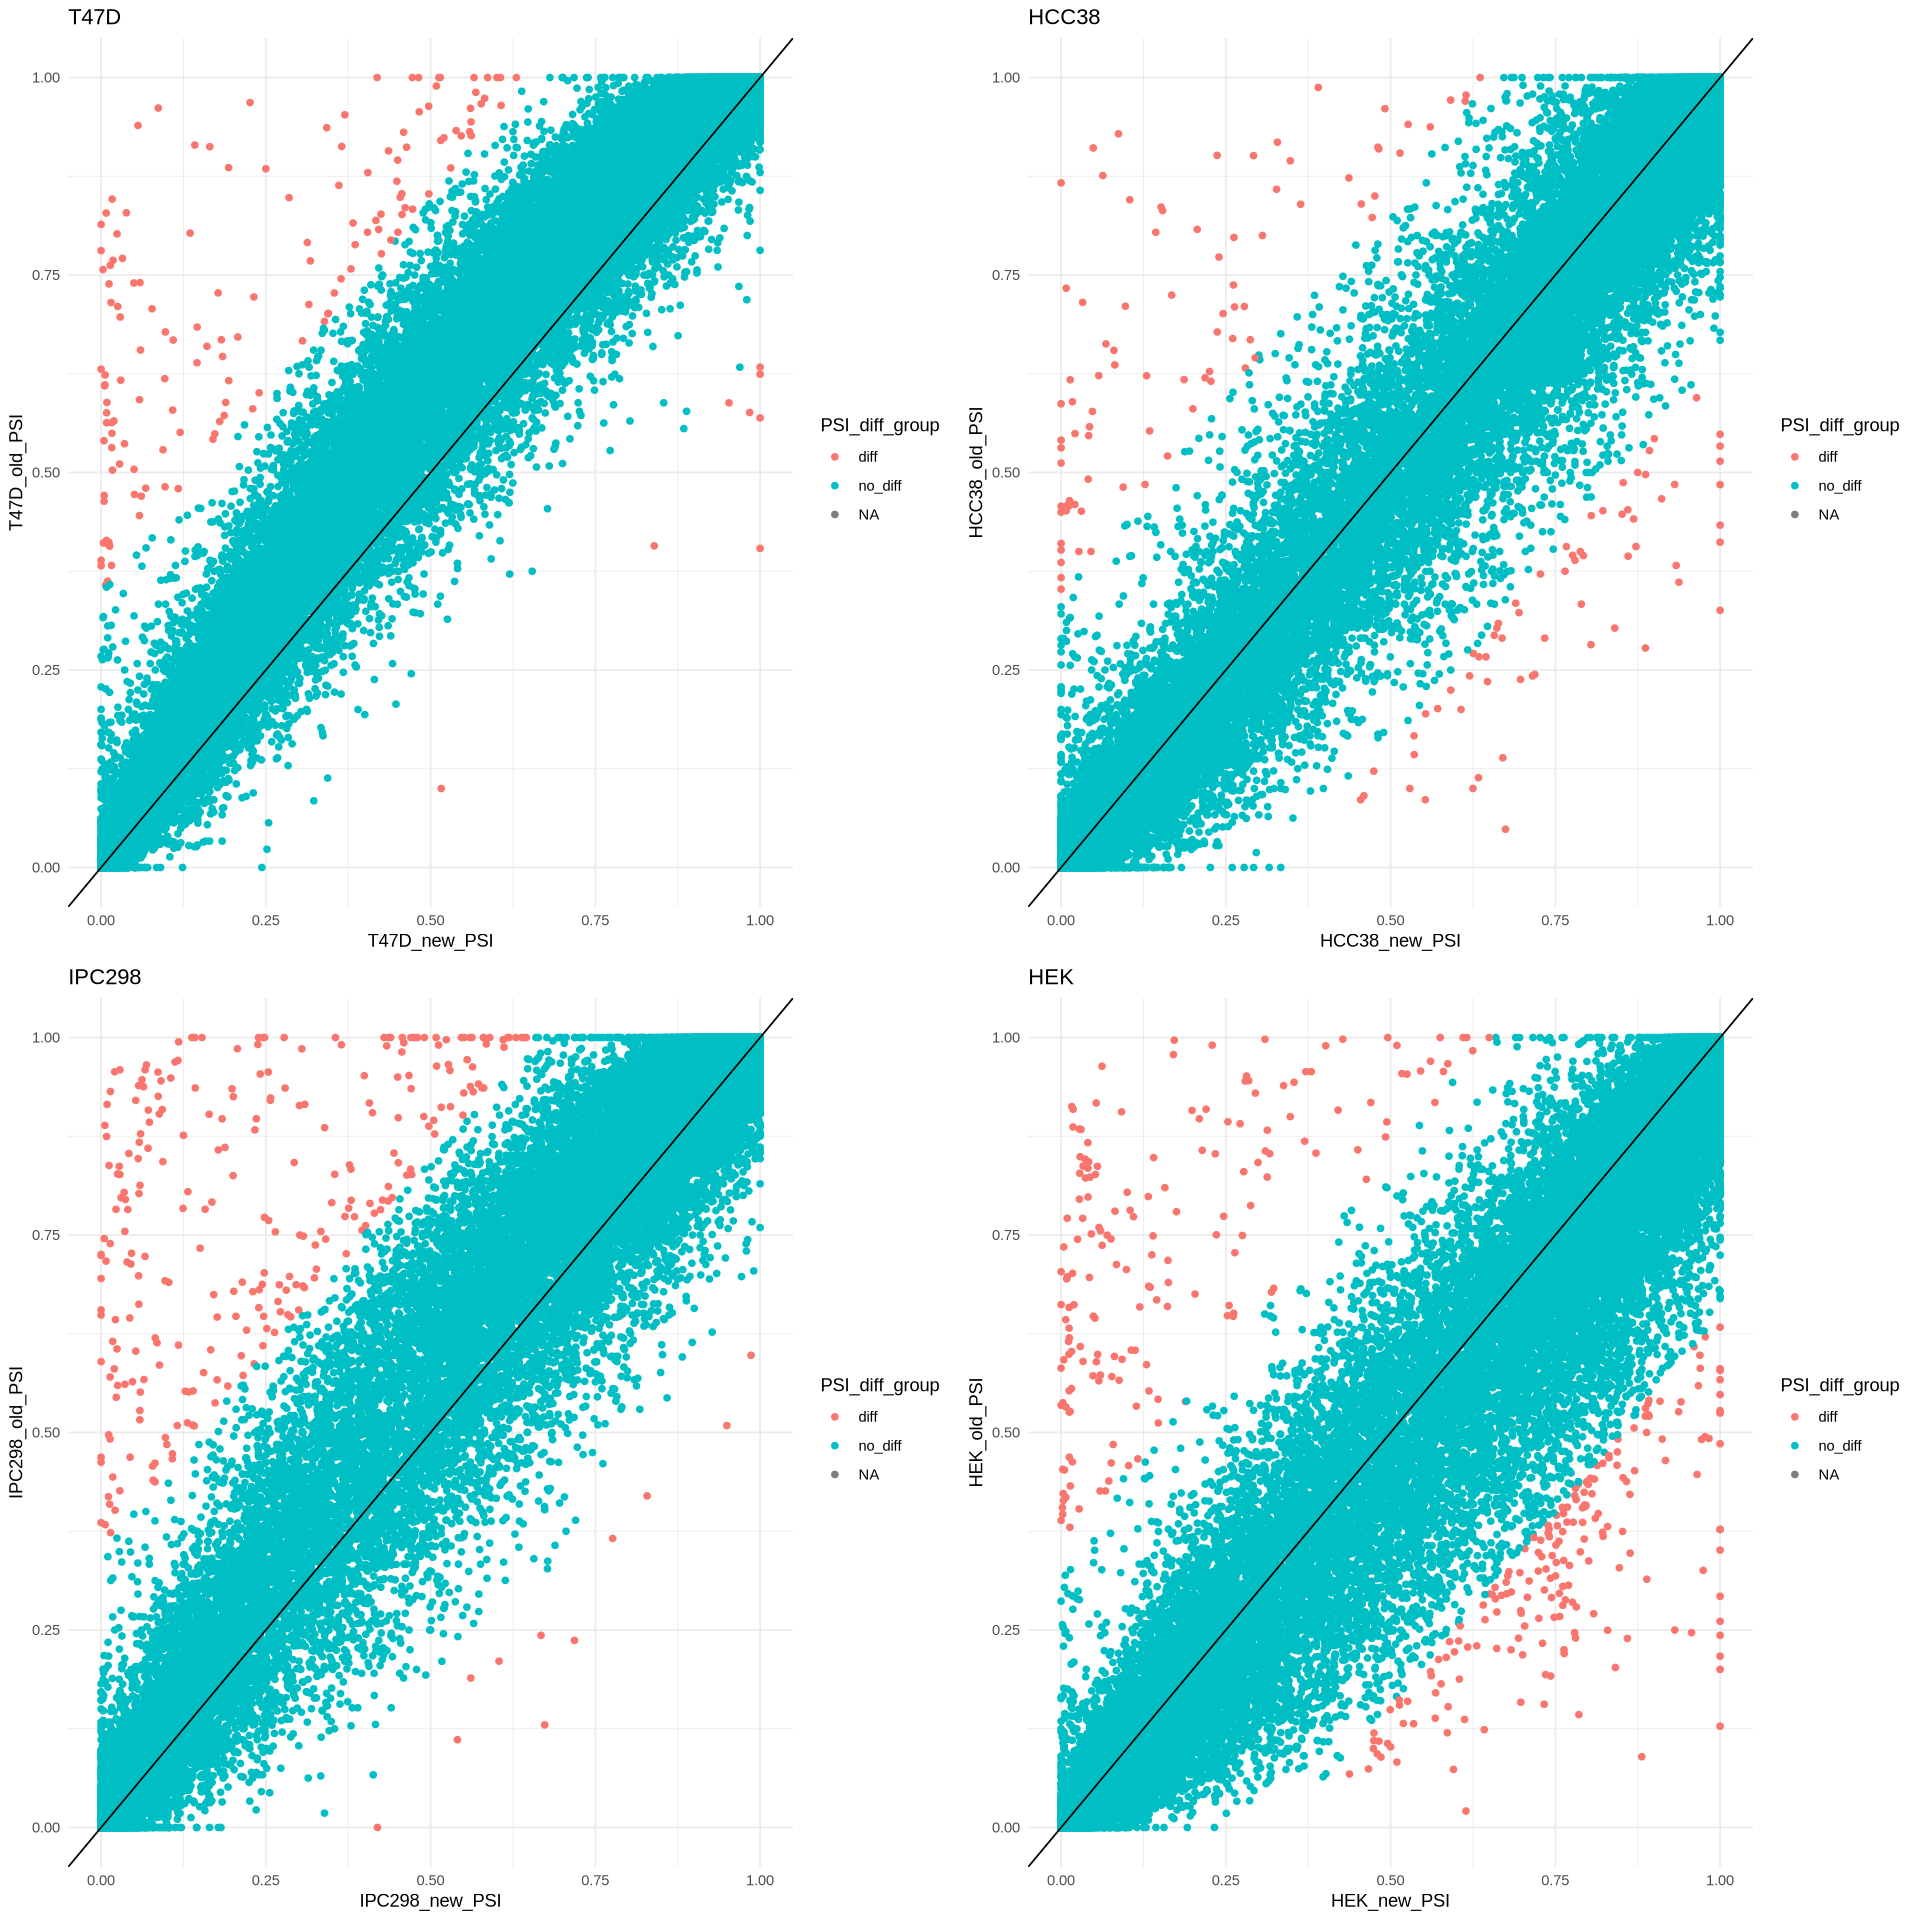

In [40]:
# Sample names in the dataset:
# '769P-rep1', '769P-rep2', '769P-rep3', '786O-rep1', '786O-rep2', '786O-rep3',
# '8MGBA_Nuc-rep1', '8MGBA_Nuc-rep2', '8MGBA_Nuc-rep3', '8MGBA_tfx-rep1', '8MGBA_tfx-rep2', '8MGBA_tfx-rep3',
# 'A172-rep1-B05_S16', 'A172-rep2-B06_S17', 'A172-rep4-B08_S19', 'A172-rep5-B09_S20', 'A172-rep6-B10_S21',
# 'A375_100tfx-rep1', 'A375_100tfx-rep2', 'A375_100tfx-rep3', 'A375_150tfx-rep1', 'A375_150tfx-rep2', 'A375_150tfx-rep3',
# 'ACHN-rep1', 'ACHN-rep2', 'ACHN-rep3', 'CAL120-rep1', 'CAL120-rep2', 'CAL120-rep3',
# 'COGN278-rep1', 'COGN278-rep2', 'COGN278-rep3', 'COLO783-rep1', 'COLO783-rep2', 'COLO783-rep3',
# 'DAOY-rep1', 'DAOY-rep2', 'DAOY-rep3', 'DBTR05MG-rep1', 'DBTR05MG-rep2', 'DBTR05MG-rep3',
# 'EFO27-rep1', 'EFO27-rep2', 'EFO27-rep3', 'GAMG-rep1', 'GAMG-rep2', 'GAMG-rep3',
# 'GB1-rep1', 'GB1-rep2', 'GB1-rep3', 'GI1-rep1', 'GI1-rep2', 'GI1-rep3',
# 'HCC1428-rep1', 'HCC1428-rep2', 'HCC1428-rep3', 'HCC38-rep1', 'HCC38-rep1-A04_S4', 'HCC38-rep2',
# 'HCC38-rep2-A05_S5', 'HCC38-rep3', 'HCC38-rep3-A06_S6', 'HEK-rep1', 'HEK-rep1-B01_S13', 'HEK-rep2',
# 'HEK-rep2-B02_S14', 'HEK-rep3', 'HEK-rep3-B03_S15', 'HEK-rep4', 'HEK-rep5', 'HEK-rep6',
# 'IGR37-rep1', 'IGR37-rep2', 'IGR37-rep3', 'index_offset', 'IPC298-rep1', 'IPC298-rep1-A07_S7',
# 'IPC298-rep2', 'IPC298-rep2-A08_S8', 'IPC298-rep3', 'IPC298-rep3-A09_S9', 'JHH6-rep1', 'JHH6-rep2', 'JHH6-rep3',
# 'JHOM-rep1', 'JHOM-rep2', 'JHOM-rep3', 'K562_2ugNuc-rep1', 'K562_2ugNuc-rep2', 'K562_2ugNuc-rep3',
# 'K562_K700E-H04_S262', 'K562_K700E-H05_S263', 'K562_K700E-H06_S264', 'K562_WT-H01_S259', 'K562_WT-H02_S260', 'K562_WT-H03_S261',
# 'Kelly-rep1', 'Kelly-rep1-A10_S10', 'Kelly-rep2', 'Kelly-rep2-A11_S11', 'Kelly-rep3', 'Kelly-rep3-A12_S12',
# 'KMRC1-rep1-B11_S22', 'KMRC1-rep2-B12_S23', 'KMRC1-rep3-C01_S24', 'KMRC1-rep4-C02_S25', 'KMRC1-rep5-C03_S26', 'KMRC1-rep6-C04_S27',
# 'KMRC20-rep1', 'KMRC20-rep1-C05_S28', 'KMRC20-rep2', 'KMRC20-rep2-C06_S29', 'KMRC20-rep3', 'KMRC20-rep3-C07_S30',
# 'KMRC20-rep4-C08_S31', 'KMRC20-rep5-C09_S32', 'KMRC20-rep6-C10_S33', 'MCF7-rep1', 'MCF7-rep2', 'MCF7-rep3',
# 'MDAMB231-rep1', 'MDAMB231-rep2', 'MDAMB231-rep3', 'MELHO-rep1', 'MELHO-rep2', 'MELHO-rep3',
# 'MEWO-rep1', 'MEWO-rep2', 'MEWO-rep3', 'OC314-rep1', 'OC314-rep2', 'OC314-rep3',
# 'OC316-rep1', 'OC316-rep2', 'OC316-rep3', 'PLCPRF5-rep1', 'PLCPRF5-rep2', 'PLCPRF5-rep3',
# 'SF126-rep1', 'SF126-rep2', 'SF126-rep3', 'SKNAS_tfx-rep1', 'SKNAS_tfx-rep2', 'SKNAS_tfx-rep3',
# 'SKNAS-rep1', 'SKNAS-rep2', 'SKNAS-rep3', 'SNU398-rep1', 'SNU398-rep2', 'SNU398-rep3',
# 'SNU423-rep1', 'SNU423-rep2', 'SNU423-rep3', 'SNU449-rep1', 'SNU449-rep2', 'SNU449-rep3',
# 'SNUC4-rep1', 'SNUC4-rep2', 'SNUC4-rep3', 'splicelib_MEL202-rep1', 'splicelib_MEL202-rep2', 'splicelib_MEL202-rep3',
# 'splicelib_MEL202-rep4', 'splicelib_MEL202-rep5', 'splicelib_MEL202-rep6', 'T47D-rep1', 'T47D-rep1-A01_S1', 'T47D-rep2',
# 'T47D-rep2-A02_S2', 'T47D-rep3', 'T47D-rep3-A03_S3', 'TOV21G-rep1', 'TOV21G-rep2', 'TOV21G-rep3',
# 'U251MG-rep1', 'U251MG-rep2', 'U251MG-rep3', 'VMRCRCZ-rep1', 'VMRCRCZ-rep2', 'VMRCRCZ-rep3'

T47D_new <- c('T47D-rep1-A01_S1', 'T47D-rep2-A02_S2', 'T47D-rep3-A03_S3')
T47D_old <- c('T47D-rep1', 'T47D-rep2', 'T47D-rep3')
HCC38_new <- c('HCC38-rep1-A04_S4', 'HCC38-rep2-A05_S5', 'HCC38-rep3-A06_S6')
HCC38_old <- c('HCC38-rep1', 'HCC38-rep2', 'HCC38-rep3')
IPC298_new <- c('IPC298-rep1-A07_S7', 'IPC298-rep2-A08_S8', 'IPC298-rep3-A09_S9')
IPC298_old <- c('IPC298-rep1', 'IPC298-rep2', 'IPC298-rep3')
HEK_new <- c('HEK-rep1-B01_S13', 'HEK-rep2-B02_S14', 'HEK-rep3-B03_S15')
HEK_old <- c('HEK-rep1', 'HEK-rep2', 'HEK-rep3')

# Now get the samples in each of these categories.
T47D_new_df <- psi_table_pivot_sample %>% 
 select(index_offset, all_of(T47D_new)) %>% 
 mutate(T47D_new_PSI = rowMeans(select(., all_of(T47D_new)), na.rm = TRUE))
T47D_old_df <- psi_table_pivot_sample %>% 
 select(index_offset, all_of(T47D_old)) %>% 
 mutate(T47D_old_PSI = rowMeans(select(., all_of(T47D_old)), na.rm = TRUE))

HCC38_new_df <- psi_table_pivot_sample %>% 
 select(index_offset, all_of(HCC38_new)) %>% 
 mutate(HCC38_new_PSI = rowMeans(select(., all_of(HCC38_new)), na.rm = TRUE))
HCC38_old_df <- psi_table_pivot_sample %>% 
 select(index_offset, all_of(HCC38_old)) %>% 
 mutate(HCC38_old_PSI = rowMeans(select(., all_of(HCC38_old)), na.rm = TRUE))

IPC298_new_df <- psi_table_pivot_sample %>% 
 select(index_offset, all_of(IPC298_new)) %>% 
 mutate(IPC298_new_PSI = rowMeans(select(., all_of(IPC298_new)), na.rm = TRUE))
IPC298_old_df <- psi_table_pivot_sample %>% 
 select(index_offset, all_of(IPC298_old)) %>% 
 mutate(IPC298_old_PSI = rowMeans(select(., all_of(IPC298_old)), na.rm = TRUE))

HEK_new_df <- psi_table_pivot_sample %>% 
 select(index_offset, all_of(HEK_new)) %>% 
 mutate(HEK_new_PSI = rowMeans(select(., all_of(HEK_new)), na.rm = TRUE))
HEK_old_df <- psi_table_pivot_sample %>% 
 select(index_offset, all_of(HEK_old)) %>% 
 mutate(HEK_old_PSI = rowMeans(select(., all_of(HEK_old)), na.rm = TRUE))

# Merge the T47D dataframes.
T47D_merged <- merge(T47D_new_df, T47D_old_df, by = "index_offset") %>%
    mutate(PSI_diff = abs(T47D_new_PSI - T47D_old_PSI)) %>% 
    mutate(PSI_diff_group = ifelse(PSI_diff < 0.35, "no_diff", "diff"))

# Merge the HCC38 dataframes.
HCC38_merged <- merge(HCC38_new_df, HCC38_old_df, by = "index_offset") %>%
    mutate(PSI_diff = abs(HCC38_new_PSI - HCC38_old_PSI)) %>% 
    mutate(PSI_diff_group = ifelse(PSI_diff < 0.35, "no_diff", "diff"))

# Merge the IPC298 dataframes.
IPC298_merged <- merge(IPC298_new_df, IPC298_old_df, by = "index_offset") %>%
    mutate(PSI_diff = abs(IPC298_new_PSI - IPC298_old_PSI)) %>% 
    mutate(PSI_diff_group = ifelse(PSI_diff < 0.35, "no_diff", "diff"))

# Merge the HEK dataframes.
HEK_merged <- merge(HEK_new_df, HEK_old_df, by = "index_offset") %>%
    mutate(PSI_diff = abs(HEK_new_PSI - HEK_old_PSI)) %>% 
    mutate(PSI_diff_group = ifelse(PSI_diff < 0.35, "no_diff", "diff"))

p1 <-ggplot(T47D_merged, aes(x = T47D_new_PSI, y = T47D_old_PSI, color = PSI_diff_group)) +
 geom_point() +
 geom_abline(slope = 1, intercept = 0) +
 xlim(0, 1) +
 ylim(0, 1) +
 theme_minimal() + 
 ggtitle("T47D")

p2 <- ggplot(HCC38_merged, aes(x = HCC38_new_PSI, y = HCC38_old_PSI, color = PSI_diff_group)) +
 geom_point() +
 geom_abline(slope = 1, intercept = 0) +
 xlim(0, 1) +
 ylim(0, 1) +
 theme_minimal() + 
 ggtitle("HCC38")

p3 <- ggplot(IPC298_merged, aes(x = IPC298_new_PSI, y = IPC298_old_PSI, color = PSI_diff_group)) +
 geom_point() + 
 geom_abline(slope = 1, intercept = 0) +
 xlim(0, 1) +
 ylim(0, 1) +
 theme_minimal() + 
 ggtitle("IPC298")

p4 <- ggplot(HEK_merged, aes(x = HEK_new_PSI, y = HEK_old_PSI, color = PSI_diff_group)) +
 geom_point() + 
 geom_abline(slope = 1, intercept = 0) +
 xlim(0, 1) +
 ylim(0, 1) +
 theme_minimal() + 
 ggtitle("HEK")

# Make the display bigger. 
options(repr.plot.width = 16, repr.plot.height = 16)
gridExtra::grid.arrange(p1, p2, p3, p4, nrow = 2, ncol = 2)

In [41]:
# Get all the sequences in the PSI_diff_group == "diff"
T47D_diff <- T47D_merged %>% filter(PSI_diff_group == "diff")
HCC38_diff <- HCC38_merged %>% filter(PSI_diff_group == "diff")
IPC298_diff <- IPC298_merged %>% filter(PSI_diff_group == "diff")
HEK_diff <- HEK_merged %>% filter(PSI_diff_group == "diff")


# Print the nrow of each dataframe.
cat("T47D_diff: ", nrow(T47D_diff), "\n")
cat("HCC38_diff: ", nrow(HCC38_diff), "\n")
cat("IPC298_diff: ", nrow(IPC298_diff), "\n")
cat("HEK_diff: ", nrow(HEK_diff), "\n")

# Print the number of intersecting sequences between the dataframes.
all_diff_sequences <- unique(c(T47D_diff$index_offset, HCC38_diff$index_offset, IPC298_diff$index_offset, HEK_diff$index_offset))
cat("Number of intersecting sequences: ", length(all_diff_sequences), "\n")

blacklist_sequences <- data.frame(index_offset = all_diff_sequences)

# Write the blacklist sequences to a file.
write.table(blacklist_sequences, file = "/mnt/dawnccle2/melange/process_fastq_250221/03_convert_to_PSI/WT_all_samples_blacklist_sequences.csv", quote = FALSE, row.names = FALSE, col.names = TRUE)




T47D_diff:  154 
HCC38_diff:  151 
IPC298_diff:  275 
HEK_diff:  372 
Number of intersecting sequences:  667 


In [39]:
barcodes_to_look_at <- c(
  "ENSG00000103274.11;NUBP1;chr16-10743960-10744065-10743785-10743882-10747142-10747276__0:0:0",
  "ENSG00000144401.14;METTL21A;chr2-207621805-207621917-207609114-207613443-207624228-207624404__0:0:0",
  "ENSG00000167110.18;GOLGA2;chr9-128258454-128258570-128257979-128258198-128259006-128259082__0:0:0",
  "ENSG00000108821.14;COL1A1;chr17-50199225-50199327-50197731-50197785-50199555-50199590__0:0:0",
  "ENSG00000180035.13;ZNF48;chr16-30395779-30395873-30378311-30378410-30397329-30397691__0:0:0",
  "ENSG00000188779.12;SKOR1;chr15-67829178-67829269-67825935-67828144-67830190-67830298__0:0:0",
  "ENSG00000174586.11;ZNF497;chr19-58358488-58358585-58354356-58357649-58362676-58362751__0:0:0"
)

T47D_merged %>% filter(index_offset %in% barcodes_to_look_at)

blacklist_sequences %>% filter(index_offset %in% barcodes_to_look_at)

index_offset,T47D-rep1-A01_S1,T47D-rep2-A02_S2,T47D-rep3-A03_S3,T47D_new_PSI,T47D-rep1,T47D-rep2,T47D-rep3,T47D_old_PSI,PSI_diff,PSI_diff_group
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
ENSG00000103274.11;NUBP1;chr16-10743960-10744065-10743785-10743882-10747142-10747276__0:0:0,0.05490196,0.052845528,0.042307692,0.050018394,0.5119048,0.5066667,0.4936709,0.5040808,0.4540624,diff
ENSG00000108821.14;COL1A1;chr17-50199225-50199327-50197731-50197785-50199555-50199590__0:0:0,0.00000000,0.000000000,0.000000000,0.000000000,0.6645570,0.5751634,0.6526316,0.6307840,0.6307840,diff
ENSG00000144401.14;METTL21A;chr2-207621805-207621917-207609114-207613443-207624228-207624404__0:0:0,0.06962025,0.209790210,0.071942446,0.117117636,0.4574468,0.5555556,0.4257426,0.4795816,0.3624640,diff
ENSG00000167110.18;GOLGA2;chr9-128258454-128258570-128257979-128258198-128259006-128259082__0:0:0,0.00000000,0.017391304,0.007812500,0.008401268,0.6078431,0.5603448,0.5585586,0.5755822,0.5671809,diff
ENSG00000174586.11;ZNF497;chr19-58358488-58358585-58354356-58357649-58362676-58362751__0:0:0,0.01346801,0.009090909,0.007462687,0.010007203,0.3144654,0.2307692,0.3269231,0.2907192,0.2807120,no_diff
ENSG00000180035.13;ZNF48;chr16-30395779-30395873-30378311-30378410-30397329-30397691__0:0:0,0.02857143,0.000000000,0.020202020,0.016257816,0.5000000,0.4736842,0.6206897,0.5314580,0.5152001,diff
ENSG00000188779.12;SKOR1;chr15-67829178-67829269-67825935-67828144-67830190-67830298__0:0:0,0.00621118,0.006024096,0.017441860,0.009892379,0.3908046,0.3766234,0.3200000,0.3624760,0.3525836,diff


index_offset
<chr>
ENSG00000103274.11;NUBP1;chr16-10743960-10744065-10743785-10743882-10747142-10747276__0:0:0
ENSG00000108821.14;COL1A1;chr17-50199225-50199327-50197731-50197785-50199555-50199590__0:0:0
ENSG00000144401.14;METTL21A;chr2-207621805-207621917-207609114-207613443-207624228-207624404__0:0:0
ENSG00000167110.18;GOLGA2;chr9-128258454-128258570-128257979-128258198-128259006-128259082__0:0:0
ENSG00000180035.13;ZNF48;chr16-30395779-30395873-30378311-30378410-30397329-30397691__0:0:0
ENSG00000188779.12;SKOR1;chr15-67829178-67829269-67825935-67828144-67830190-67830298__0:0:0
ENSG00000174586.11;ZNF497;chr19-58358488-58358585-58354356-58357649-58362676-58362751__0:0:0
